In [ ]:
import sys

sys.path.append('..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib.patches import Patch
from PIL import Image
from skimage.transform import rescale
from torchvision import transforms

from virtuesm2.models.virtuesm2_hf import VirTuesM2_HF
from virtuesm2.segmentation.decoder import SegmentationDecoder
from virtuesm2.utils.utils import load_marker_embedding_dict

#### Load the multiplex and H&E sample crop

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

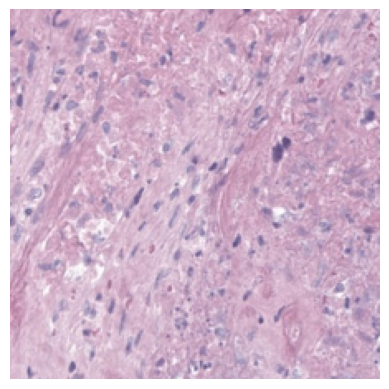

In [2]:
mx_image_raw = np.load("../example_data/mx_example_crop_1.npy")
mx_image_raw = torch.tensor(mx_image_raw)
he_image_raw = np.array(Image.open("../example_data/he_example_crop_1.png").convert("RGB"))
he_image_raw = torch.tensor(he_image_raw)

cell_type_labels = ['None', 'Stroma', 'Endothelia', 'Macrophage', 'Tumor', \
    'Helper T cell', 'Cytotoxic T cell', 'Other', 'Treg', 'B cells']

plt.imshow(he_image_raw)
plt.axis("off")

#### Load ESM-2 embeddings

In [3]:
esm_embeddings = load_marker_embedding_dict("../example_data/esm_embeddings")

# esm embeddings for channels
marker_names = pd.read_csv("../example_data/gene_dict.csv")

In [4]:
mx_image = mx_image_raw[marker_names["protein_id"].values != "Exclude"]
uniprot_ids = marker_names["protein_id"].values[marker_names["protein_id"].values != "Exclude"]
uniprot_indices = torch.tensor([esm_embeddings[uniprot_id] for uniprot_id in uniprot_ids]).unsqueeze(0)

#### Apply Normalization

In [5]:
mean_he = [0.7068, 0.5755, 0.722]
std_he = [0.195, 0.2316, 0.1816]
he_normalization = transforms.Normalize(mean=mean_he, std=std_he)
he_undo_normalization = transforms.Normalize(mean=[-m/s for m, s in zip(mean_he, std_he)], std=[1/s for s in std_he])

# Q99 normalization
clip_values = pd.read_csv("../example_data/q99.csv")
valid_markers = marker_names["name"].values[marker_names["protein_id"].values != "Exclude"]
clip_values = torch.tensor(clip_values[valid_markers].values[0])

In [6]:
he_image = he_normalization(he_image_raw.permute(2,0,1)/255.0)
mx_image = torch.clamp(mx_image, min=torch.zeros_like(mx_image), max=clip_values.view(-1,1,1)) / clip_values.view(-1,1,1)
mx_image = mx_image.half()

In [7]:
he_image = he_normalization(he_image_raw.permute(2,0,1)/255.0)
mx_image = torch.clamp(mx_image, min=torch.zeros_like(mx_image), max=clip_values.view(-1,1,1)) / clip_values.view(-1,1,1)
mx_image = mx_image.half()

rescale_factor = 1.75
if rescale_factor != 1.0:
    mx_image = rescale(mx_image.numpy(), scale=rescale_factor, channel_axis=0, preserve_range=True, anti_aliasing=True)
    mx_image = torch.tensor(mx_image[:, :224, :224]).cuda(non_blocking=True)
    he_image = rescale(he_image.numpy(), scale=rescale_factor, channel_axis=0, preserve_range=True, anti_aliasing=True)
    he_image = torch.tensor(he_image[:, :224, :224]).cuda(non_blocking=True)

#### Create Model

In [ ]:
marker_embedding_dir = "../example_data/esm_embeddings"

# VirTues-M2
model = VirTuesM2_HF.from_pretrained("bunnelab/virtues-m2", marker_embedding_dir=marker_embedding_dir, force_download=True)
model.cuda()
model.eval()

# Segmentation decoder
segmentation_decoder = SegmentationDecoder(
    num_nuclei_classes=len(cell_type_labels),
    embed_dim = 1024 + 1024,
    extract_layers=[6, 12, 18, 24],
)
segmentation_decoder_weights = torch.load("...")
segmentation_decoder.load_state_dict(segmentation_decoder_weights["cellvit_state_dict"])
segmentation_decoder.cuda()
segmentation_decoder.eval()


SegmentationDecoder(
  (decoder0): Sequential(
    (0): Deconv2DBlock(
      (block): Sequential(
        (0): ConvTranspose2d(2048, 512, kernel_size=(2, 2), stride=(2, 2))
        (1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): ReLU(inplace=True)
        (4): Dropout(p=0, inplace=False)
      )
    )
    (1): Deconv2DBlock(
      (block): Sequential(
        (0): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): ReLU(inplace=True)
        (4): Dropout(p=0, inplace=False)
      )
    )
    (2): Deconv2DBlock(
      (block): Sequential(
        (0): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
        (1): Conv2d(128, 128, kernel_size=(3, 3), str

#### Forward pass through VirTues-M2 + Segmentation Decoder

In [9]:
num_patches = mx_image.shape[1] * mx_image.shape[2] // (14*14)

with torch.inference_mode():
    with torch.amp.autocast("cuda", dtype=torch.float16):
        mx_image = mx_image.cuda()
        he_image = he_image.cuda()

        # Get the tokenized multiplex and H&E inputs
        tokenized_img = model.prepare_tokens_with_masks(mx_image.unsqueeze(0), he_image.unsqueeze(0), uniprot_indices)
        tokens_mx = tokenized_img[:, model.num_register_tokens + 1: + model.num_register_tokens + 1 + num_patches]
        tokens_he = tokenized_img[:, model.num_register_tokens + 1 + num_patches:]

        # Apply VirTues-M2
        mm_embeddings = model.forward_features(mx_image.unsqueeze(0), he_image.unsqueeze(0), uniprot_indices, return_all_layers=True)
        x_all_layers = mm_embeddings["x_all_layers"]
        for i in range(len(x_all_layers)):
            x_all_layers[i] = torch.cat((x_all_layers[i][:, 1 + model.num_register_tokens : 1 + model.num_register_tokens + num_patches],
                                        x_all_layers[i][:, 1 + model.num_register_tokens + num_patches:]),
                                        dim=-1)
        
        # Decoder images into segmentation maps
        patches_concat = torch.cat((tokens_mx, tokens_he), dim=-1)
        segmentation_output = segmentation_decoder(patches_concat, x_all_layers)

#### Plot the direct outputs

In [10]:
binary_nucleus_map = segmentation_output["nuclei_binary_map"]
hv_map = segmentation_output["hv_map"]
nucleus_type_prediction = segmentation_output["nuclei_type_map"]
nucleus_type_prediction_nonzero = torch.argmax(nucleus_type_prediction[:, 1:], dim=1).squeeze().cpu().numpy() + 1
nucleus_type_prediction = torch.argmax(nucleus_type_prediction, dim=1).squeeze().cpu().numpy()

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

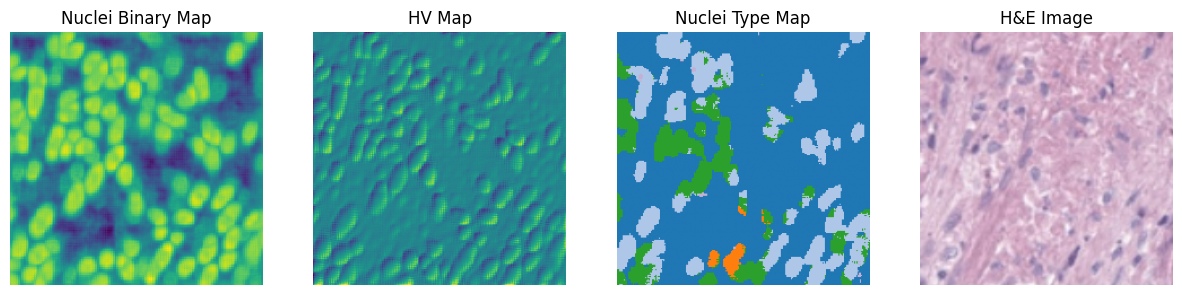

In [11]:
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].imshow(binary_nucleus_map.cpu().numpy()[0, 1])
axs[0].set_title("Nuclei Binary Map")
axs[0].axis("off")
axs[1].imshow((hv_map.cpu().numpy()[0,0] + hv_map.cpu().numpy()[0,1]))
axs[1].set_title("HV Map")
axs[1].axis("off")
axs[2].imshow(nucleus_type_prediction.astype(float), cmap="tab20", vmin=0, vmax=20)
axs[2].set_title("Nuclei Type Map")
axs[2].axis("off")
axs[3].imshow(he_undo_normalization(he_image).cpu().numpy().transpose(1,2,0))
axs[3].set_title("H&E Image")
axs[3].axis("off")

#### Post-Processing

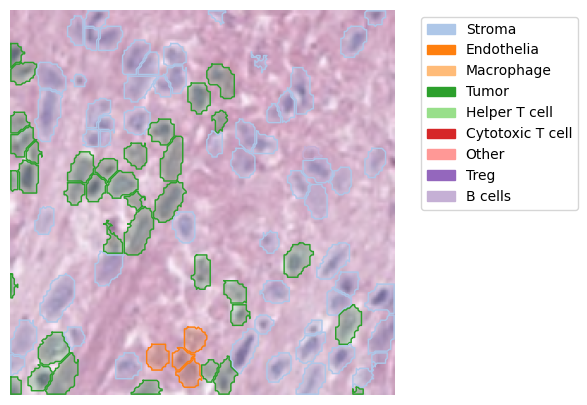

In [12]:
instance_map, contours = segmentation_decoder.calculate_instance_map(segmentation_output, magnification=10)

fig, axs = plt.subplots(figsize=(5, 5))
tab_20_colors = sns.color_palette("tab20", n_colors=20).as_hex()
plt.imshow(he_undo_normalization(he_image).cpu().numpy().transpose(1,2,0))

for cell_id, cell_info in contours[0].items():
    contour = cell_info['contour']
    cell_type = cell_info['centroid'].astype(int)
    cell_type = nucleus_type_prediction_nonzero[cell_type[1], cell_type[0]]
    # Close the contour by appending the first point at the end
    closed_contour = np.vstack([contour, contour[0]])
    axs.plot(closed_contour[:, 0], closed_contour[:, 1], color=tab_20_colors[cell_type], linewidth=1)
    axs.fill(closed_contour[:, 0], closed_contour[:, 1], color=tab_20_colors[cell_type], alpha=0.2)
plt.axis("off")

# add legend
# patch
handles = [Patch(color=tab_20_colors[i], label=cell_type_labels[i]) for i in range(1, len(cell_type_labels))]
plt.legend(handles, cell_type_labels[1:], bbox_to_anchor=(1.05, 1), loc='upper left')